# <center> Проект: Анализ резюме из HeadHunter
   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла.

In [ ]:
df = pd.read_csv("data/dst-3.0_16_1_hh_database.csv", encoding='utf-8', sep=';')
df.shape

(44744, 12)

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [ ]:
df.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

4. Обратите внимание на информацию о числе непустых значений.

In [ ]:
df.isnull().sum() #кол-во null в столбцах

,0
"Пол, возраст",0
ЗП,0
Ищет работу на должность:,0
"Город, переезд, командировки",0
Занятость,0
График,0
Опыт работы,168
Последнее/нынешнее место работы,1
Последняя/нынешняя должность,2
Образование и ВУЗ,0


5. Выведите основную статистическую информацию о столбцах.


In [ ]:
df.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [ ]:
def extract_education_level(education_text):
    if pd.isna(education_text):
        return None

    text = str(education_text)
    first_three_words = ' '.join(text.split()[:3])

    if text.startswith('Высшее образование'):
        return 'высшее'
    elif text.startswith('Неоконченное высшее образование'):
        return 'неоконченное высшее'
    elif text.startswith('Среднее специальное образование'):
        return 'среднее специальное'
    elif text.startswith('Среднее образование'):
        return 'среднее'
    else:
        return None

df['Образование'] = df['Образование и ВУЗ'].apply(extract_education_level)
df = df.drop(columns=['Образование и ВУЗ'])
df['Образование'].value_counts(dropna=False)

,count
Образование,
высшее,33863
среднее специальное,5765
неоконченное высшее,4557
среднее,559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина.
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '.
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [ ]:
df['Пол'] = df['Пол, возраст'].apply(
    lambda x: 'М' if str(x).split(' , ')[0].strip() == 'Мужчина'
    else 'Ж' if str(x).split(' , ')[0].strip() == 'Женщина'
    else None
)

df['Возраст'] = df['Пол, возраст'].apply(
    lambda x: int(''.join(filter(str.isdigit, str(x).split(' , ')[1].strip())))
    if pd.notna(x) and len(str(x).split(' , ')) > 1
    else None
)

df = df.drop(columns=['Пол, возраст'])

In [ ]:
total_resumes = len(df)
female_count = df['Пол'].value_counts().get('Ж', 0)
female_percentage = (female_count / total_resumes) * 100
print(f"Процент женских резюме: {female_percentage:.2f}%")


average_age = df['Возраст'].mean()
print(f"Средний возраст соискателей: {average_age:.2f} лет")

Процент женских резюме: 19.07%
Средний возраст соискателей: 32.20 лет


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**.

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [ ]:
def extract_experience(text):
    if pd.isna(text) or str(text).strip() == 'Не указано':
        return np.nan

    text = str(text).split(',')[0].lower()
    words = text.split()

    years = 0
    months = 0

    for i in range(len(words)):
        if words[i].isdigit() and i + 1 < len(words):
            if any(year_word in words[i + 1] for year_word in ['год', 'лет', 'года']):
                years = int(words[i])
                break

    for i in range(len(words)):
        if words[i].isdigit() and i + 1 < len(words):
            if any(month_word in words[i + 1] for month_word in ['месяц', 'месяца', 'месяцев']):
                months = int(words[i])
                break

    return years * 12 + months

In [ ]:
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(extract_experience)
df = df.drop(columns=['Опыт работы'])
df['Опыт работы (месяц)'].median()

100.0

In [ ]:
#19199 #26781

4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , …
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [ ]:
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань',
                  'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа',
                  'Красноярск', 'Пермь', 'Воронеж', 'Волгоград' ]

def extract_city_info(text):
    if pd.isna(text):
        return 'другие', False, False

    parts = [part.strip() for part in text.split(' , ')]

    if 'м. ' in parts[1]:
        parts.remove(parts[1])

    city = parts[0]
    if city == 'Москва':
        city_category = 'Москва'
    elif city == 'Санкт-Петербург':
        city_category = 'Санкт-Петербург'
    elif city in million_cities:
        city_category = 'город-миллионник'
    else:
        city_category = 'другие'

    relocation = False
    for part in parts:
        part = part.lower()
        if any(word in part for word in ['готов к переезду', 'готова к переезду',
                                         'хочу переехать', 'готов к релокации']) and 'не ' not in part:
            relocation = True
            break

    business_trips = False
    for part in parts:
        part = part.lower()
        if any(word in part for word in ['готов к командировкам', 'готова к командировкам',
                                         'готов к командировке', 'редким командировкам',
                                         'редким командировкам']) and 'не ' not in part:
            business_trips = True
            break

    return city_category, relocation, business_trips

df[['Город', 'Готовность к переезду', 'Готовность к командировкам']] = df['Город, переезд, командировки'].apply(
    lambda x: pd.Series(extract_city_info(x))
)
df = df.drop(columns=['Город, переезд, командировки'])

In [ ]:
total_resumes = len(df)
spb_count = (df['Город'] == 'Санкт-Петербург').sum()
spb_percentage = (spb_count / total_resumes) * 100

print(f"Общее количество резюме: {total_resumes}")
print(f"Количество соискателей в Санкт-Петербурге: {spb_count}")
print(f"Процент соискателей в Санкт-Петербурге: {spb_percentage:.1f}%")

both_ready = ((df['Готовность к переезду'] == True) &
              (df['Готовность к командировкам'] == True)).sum()
both_ready_percentage = (both_ready / total_resumes) * 100

print(f"\nКоличество готовых к переезду и командировкам: {both_ready}")
print(f"Процент готовых к переезду и командировкам: {both_ready_percentage:.1f}%")

Общее количество резюме: 44744
Количество соискателей в Санкт-Петербурге: 4937
Процент соискателей в Санкт-Петербурге: 11.0%

Количество готовых к переезду и командировкам: 14258
Процент готовых к переезду и командировкам: 31.9%


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [ ]:
employment_categories = ['полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']
schedule_categories = ['полный день', 'сменный график', 'гибкий график', 'удаленная работа', 'вахтовый метод']

def create_binary_features(df, column, categories):

    for category in categories:
        new_column_name = f"{column} {category}"
        df[new_column_name] = df[column].apply(
            lambda x: category in str(x) if pd.notna(x) else False
        )

create_binary_features(df, 'Занятость', employment_categories)
create_binary_features(df, 'График', schedule_categories)
df = df.drop(columns=['Занятость', 'График'])

In [ ]:
project_and_volunteer = ((df['Занятость проектная работа'] == True) &
                         (df['Занятость волонтерство'] == True)).sum()

print(f"Количество людей, ищущих проектную работу и волонтерство: {project_and_volunteer}")

shift_and_flexible = ((df['График вахтовый метод'] == True) &
                      (df['График гибкий график'] == True)).sum()

print(f"Количество людей, желающих вахтовый метод и гибкий график: {shift_and_flexible}")

Количество людей, ищущих проектную работу и волонтерство: 436
Количество людей, желающих вахтовый метод и гибкий график: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**.
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата,
* "proportion" - пропорция,
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования:
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [ ]:
currency_df = pd.read_csv('data/ExchangeRates.csv')
df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], format='%d.%m.%Y %H:%M').dt.date
currency_df['date'] = pd.to_datetime(currency_df['date'], format='%d/%m/%y').dt.date

currency_mapping = {
    'руб.': 'RUB',
    'грн.': 'UAH',
    'USD': 'USD',
    'EUR': 'EUR',
    'бел.руб.': 'BYN',
    'KGS': 'KGS',
    'сум': 'UZS',
    'AZN': 'AZN',
    'KZT': 'KZT'
}

rub_dates = pd.DataFrame({
    'date': df['Обновление резюме'].unique(),
    'currency': 'RUB',
    'proportion': 1,
    'close': 1.0
})

currency_df = pd.concat([currency_df, rub_dates], ignore_index=True)

def extract_salary_currency(salary_text):
    if pd.isna(salary_text):
        return None, None

    text = salary_text.strip()
    parts = text.split()
    amount = parts[0]
    currency = parts[1]
    currency_iso = currency_mapping.get(currency, currency)
    return int(amount), currency_iso

df[['ЗП сумма', 'ЗП валюта']] = df['ЗП'].apply(
    lambda x: pd.Series(extract_salary_currency(x))
)


In [ ]:
df = df.merge(
    currency_df,
    left_on=['Обновление резюме', 'ЗП валюта'],
    right_on=['date', 'currency'],
    how='left'
)

df['ЗП (руб)'] = df['ЗП сумма'] * df['close'] / df['proportion']

df = df.drop(columns=['ЗП', 'ЗП сумма', 'ЗП валюта', 'currency', 'per',
                      'date', 'time', 'close', 'vol', 'proportion'])

print(f"Медианная ЗП в рублях: {df['ЗП (руб)'].median()}")

Медианная ЗП в рублях: 59019.0


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

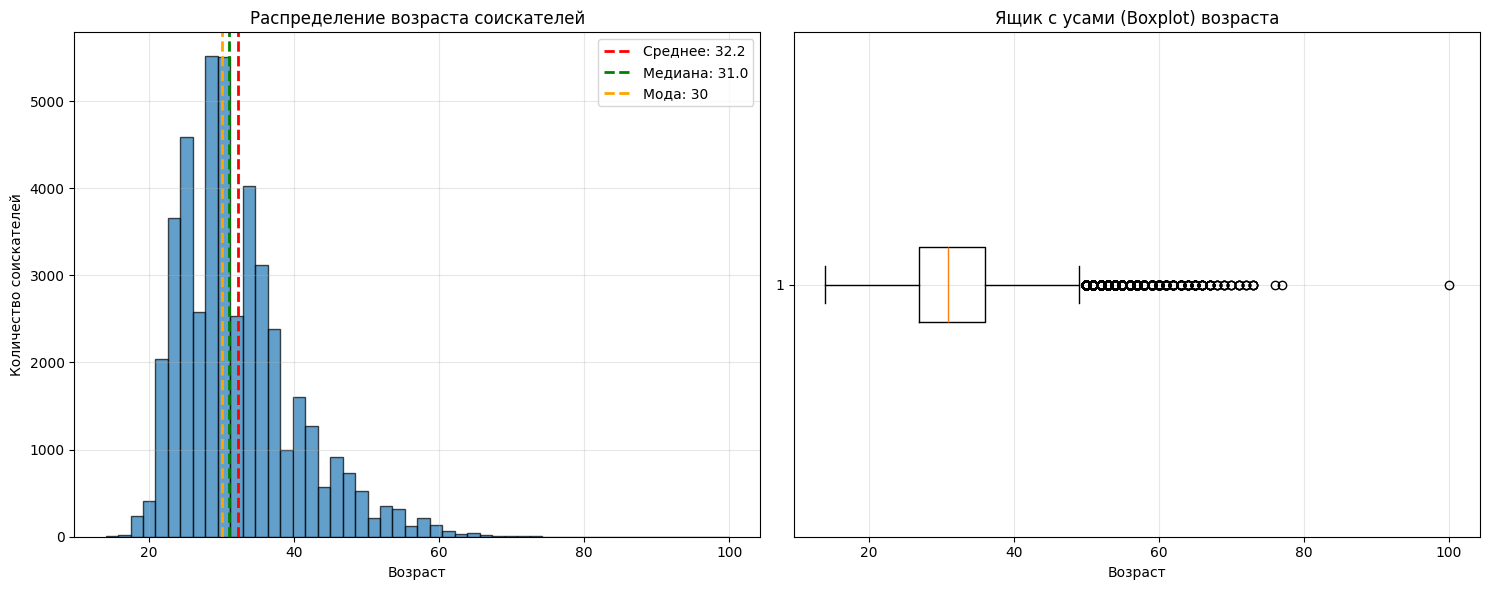

Основные статистики возраста:

Минимальный возраст: 14 лет
Максимальный возраст: 100 лет
Средний возраст: 32.19674146254246 лет
Медианный возраст: 31.0 лет
Мода возраста: 30 лет
Стандартное отклонение: 7.9297998974240596 лет

25-й перцентиль (Q1): 27.0 лет
75-й перцентиль (Q3): 36.0 лет
Межквартильный размах (IQR): 9.0 лет

Нижняя граница выбросов: 13.5 лет
Верхняя граница выбросов: 49.5 лет
Количество выбросов (нижние): 0
Количество выбросов (верхние): 1774

Процент соискателей в возрасте 25-45 лет: 78.5%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(df['Возраст'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Количество соискателей')
ax1.set_title('Распределение возраста соискателей')
ax1.grid(True, alpha=0.3)

mean_age = df['Возраст'].mean()
median_age = df['Возраст'].median()
mode_age = df['Возраст'].mode()[0]

ax1.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_age:.1f}')
ax1.axvline(median_age, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_age:.1f}')
ax1.axvline(mode_age, color='orange', linestyle='--', linewidth=2, label=f'Мода: {mode_age:.0f}')
ax1.legend()

ax2.boxplot(df['Возраст'].dropna(), vert=False)
ax2.set_xlabel('Возраст')
ax2.set_title('Ящик с усами (Boxplot) возраста')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""Основные статистики возраста:\n
Минимальный возраст: {df['Возраст'].min()} лет
Максимальный возраст: {df['Возраст'].max()} лет
Средний возраст: {df['Возраст'].mean()} лет
Медианный возраст: {df['Возраст'].median()} лет
Мода возраста: {df['Возраст'].mode()[0]} лет
Стандартное отклонение: {df['Возраст'].std()} лет""")

Q1 = df['Возраст'].quantile(0.25)
Q3 = df['Возраст'].quantile(0.75)
IQR = Q3 - Q1
print(f"\n25-й перцентиль (Q1): {Q1:.1f} лет")
print(f"75-й перцентиль (Q3): {Q3:.1f} лет")
print(f"Межквартильный размах (IQR): {IQR:.1f} лет")

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nНижняя граница выбросов: {lower_bound:.1f} лет")
print(f"Верхняя граница выбросов: {upper_bound:.1f} лет")

# Количество выбросов
outliers_lower = df[df['Возраст'] < lower_bound]['Возраст'].count()
outliers_upper = df[df['Возраст'] > upper_bound]['Возраст'].count()
print(f"Количество выбросов (нижние): {outliers_lower}")
print(f"Количество выбросов (верхние): {outliers_upper}")

# Процент соискателей в основном интервале
main_interval_count = df[(df['Возраст'] >= 25) & (df['Возраст'] <= 45)]['Возраст'].count()
main_interval_percent = (main_interval_count / len(df)) * 100
print(f"\nПроцент соискателей в возрасте 25-45 лет: {main_interval_percent:.1f}%")

In [ ]:
high_salary_count = (df['ЗП (руб)'] > 1000000).sum()
high_salary_count

np.int64(5)

Мода распределения составляет 30 лет, что соответствует периоду активного карьерного роста и поиска работы после получения значимого опыта работы.

Основной интервал - большинство соискателей (78.5%) сосредоточены в возрастном диапазоне 25-45 лет. Это главная составляющая рынка труда - люди в периоде активной карьеры.


Характер распределения:

- Распределение имеет правую асимметрию
- Среднее значение превышает медианное
- Наблюдается выраженный пик в молодых возрастных группах

Возраст является важным фактором при анализе рынка труда, отражая разные стратегии поиска работы и карьерные этапы соискателей.

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

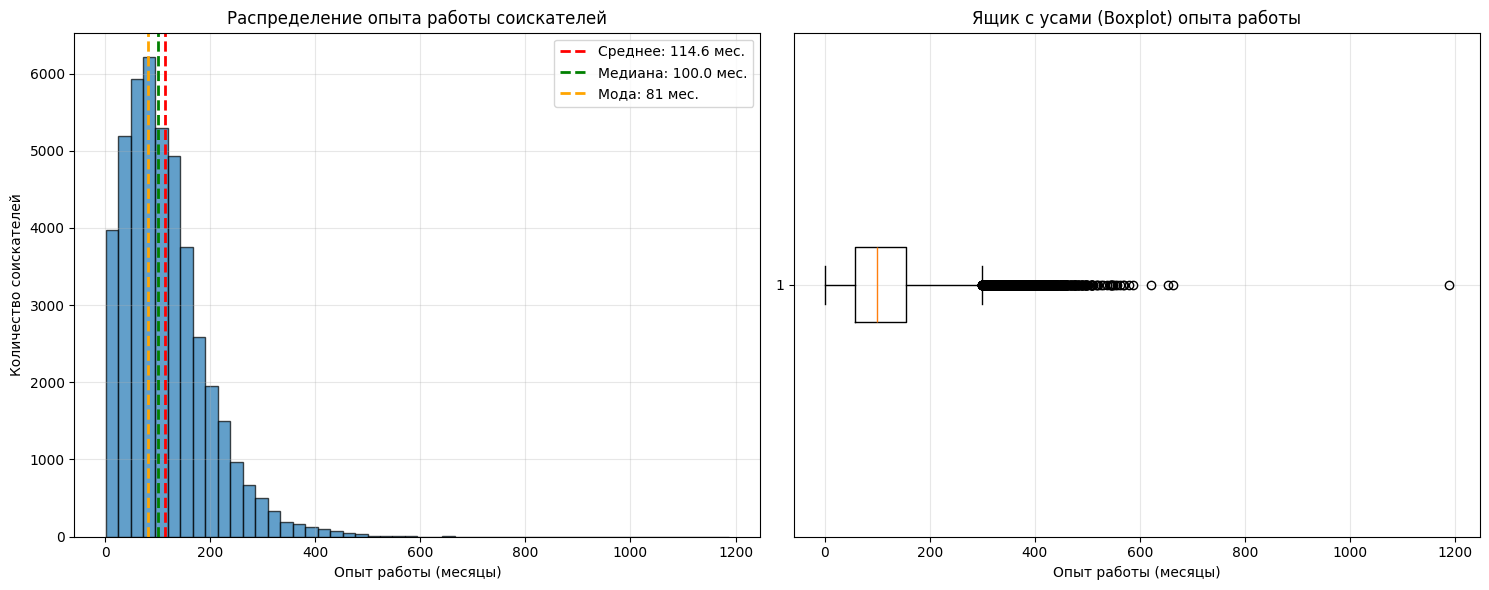

Основные статистики опыта работы:
Минимальный опыт: 1 мес.
Максимальный опыт: 1188 мес.
Средний опыт: 114.6 мес.
Медианный опыт: 100.0 мес.
Мода опыта: 81 мес.
Стандартное отклонение: 79.1 мес.

25-й перцентиль (Q1): 57.0 мес.
75-й перцентиль (Q3): 154.0 мес.
Межквартильный размах (IQR): 97.0 мес.

Нижняя граница выбросов: -88.5 мес.
Верхняя граница выбросов: 299.5 мес.
Количество выбросов (нижние): 0
Количество выбросов (верхние): 1276

Процент соискателей с опытом 1-10 лет: 56.4%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(df['Опыт работы (месяц)'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Опыт работы (месяцы)')
ax1.set_ylabel('Количество соискателей')
ax1.set_title('Распределение опыта работы соискателей')
ax1.grid(True, alpha=0.3)

mean_exp = df['Опыт работы (месяц)'].mean()
median_exp = df['Опыт работы (месяц)'].median()
mode_exp = df['Опыт работы (месяц)'].mode()[0]

ax1.axvline(mean_exp, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_exp:.1f} мес.')
ax1.axvline(median_exp, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_exp:.1f} мес.')
ax1.axvline(mode_exp, color='orange', linestyle='--', linewidth=2, label=f'Мода: {mode_exp:.0f} мес.')
ax1.legend()

ax2.boxplot(df['Опыт работы (месяц)'].dropna(), vert=False)
ax2.set_xlabel('Опыт работы (месяцы)')
ax2.set_title('Ящик с усами (Boxplot) опыта работы')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""Основные статистики опыта работы:
Минимальный опыт: {df['Опыт работы (месяц)'].min():.0f} мес.
Максимальный опыт: {df['Опыт работы (месяц)'].max():.0f} мес.
Средний опыт: {df['Опыт работы (месяц)'].mean():.1f} мес.
Медианный опыт: {df['Опыт работы (месяц)'].median():.1f} мес.
Мода опыта: {df['Опыт работы (месяц)'].mode()[0]:.0f} мес.
Стандартное отклонение: {df['Опыт работы (месяц)'].std():.1f} мес.""")

Q1 = df['Опыт работы (месяц)'].quantile(0.25)
Q3 = df['Опыт работы (месяц)'].quantile(0.75)
IQR = Q3 - Q1
print(f"\n25-й перцентиль (Q1): {Q1:.1f} мес.")
print(f"75-й перцентиль (Q3): {Q3:.1f} мес.")
print(f"Межквартильный размах (IQR): {IQR:.1f} мес.")

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nНижняя граница выбросов: {lower_bound:.1f} мес.")
print(f"Верхняя граница выбросов: {upper_bound:.1f} мес.")

# Количество выбросов
outliers_lower = df[df['Опыт работы (месяц)'] < lower_bound]['Опыт работы (месяц)'].count()
outliers_upper = df[df['Опыт работы (месяц)'] > upper_bound]['Опыт работы (месяц)'].count()
print(f"Количество выбросов (нижние): {outliers_lower}")
print(f"Количество выбросов (верхние): {outliers_upper}")

# Процент соискателей в основном интервале
main_interval_count = df[(df['Опыт работы (месяц)'] >= 12) & (df['Опыт работы (месяц)'] <= 120)]['Опыт работы (месяц)'].count()
main_interval_percent = (main_interval_count / len(df)) * 100
print(f"\nПроцент соискателей с опытом 1-10 лет: {main_interval_percent:.1f}%")

In [ ]:
max_experience = df['Опыт работы (месяц)'].max()
max_experience

1188.0

Мода распределения составляет 81 месяц (около 7 лет), что указывает на значительную группу соискателей с опытом работы, соответствующим переходу на позиции среднего и высокого уровня.

Основной интервал - большинство соискателей (56.4%) имеют опыт работы от 1 до 10 лет. Это соответствует периоду профессионального становления и активного карьерного роста.

Верхние аномалии - 1276 соискателей имеют опыт работы более 299.5 месяцев (25 лет), при этом максимальное значение 1188 месяцев физически невозможно и является ошибкой данных. Также опыт работы более 35-40 лет следует считать аномалиями.

Характер распределения:

- Распределение имеет правую асимметрию

- Средний опыт (114.6 месяцев) превышает медианный (100 месяцев)

- Наблюдается концентрация в диапазоне 5-13 лет опыта

Опыт работы является одним из ключевым факторов при анализе профессиональных характеристик соискателей. Основная масса соискателей имеет опыт, достаточный для занятия позиций специалистов и средних руководителей, что отражает здоровую динамику рынка труда.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


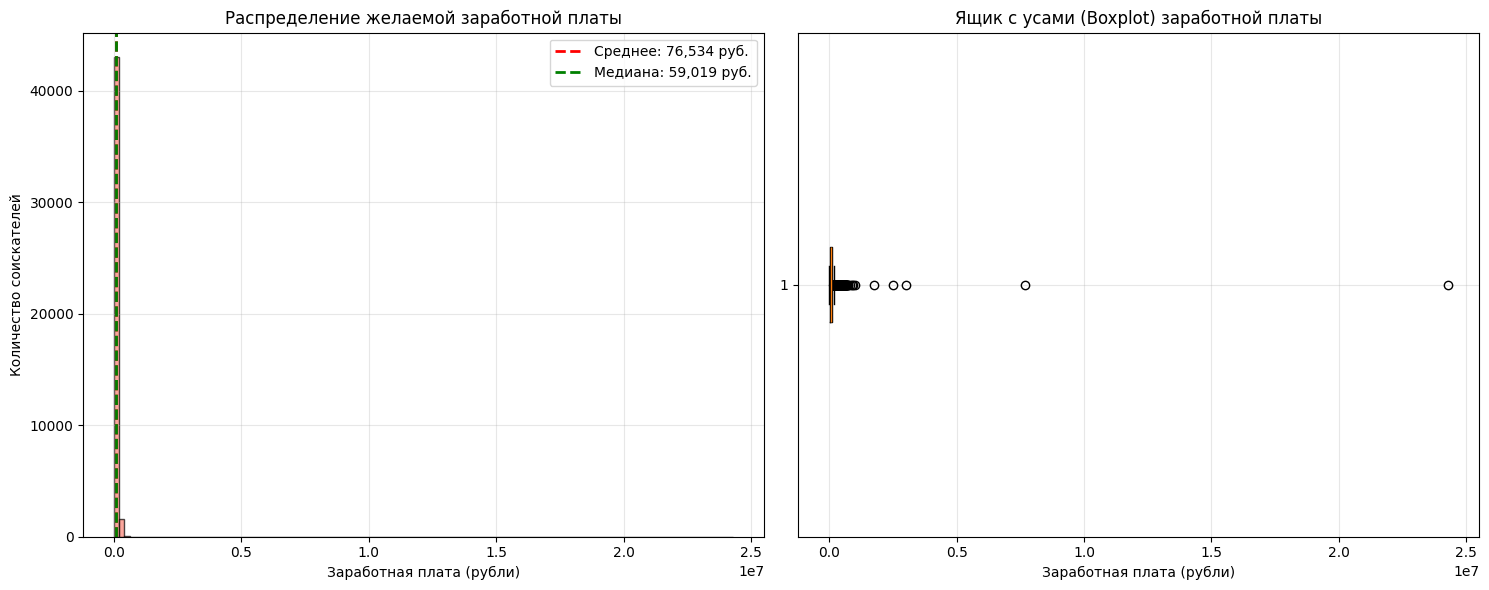

ОСНОВНЫЕ СТАТИСТИКИ ЗАРПЛАТЫ:
Минимальная ЗП: 1 руб.
Максимальная ЗП: 24,304,876 руб.
Средняя ЗП: 76,534 руб.
Медианная ЗП: 59,019 руб.
Стандартное отклонение: 135,932 руб.

25-й перцентиль (Q1): 37,082 руб.
75-й перцентиль (Q3): 95,000 руб.
Межквартильный размах (IQR): 57,918 руб.

Нижняя граница выбросов: -49,795 руб.
Верхняя граница выбросов: 181,877 руб.
Количество выбросов (нижние): 0
Количество выбросов (верхние): 2781

Процент соискателей с ЗП 20k-150k руб.: 88.3%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Создаем subplot с двумя графиками рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Гистограмма
ax1.hist(df['ЗП (руб)'].dropna(), bins=120, edgecolor='black', alpha=0.7, color='salmon')
ax1.set_xlabel('Заработная плата (рубли)')
ax1.set_ylabel('Количество соискателей')
ax1.set_title('Распределение желаемой заработной платы')
ax1.grid(True, alpha=0.3)

# Добавим вертикальные линии для статистик
mean_salary = df['ЗП (руб)'].mean()
median_salary = df['ЗП (руб)'].median()

ax1.axvline(mean_salary, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_salary:,.0f} руб.')
ax1.axvline(median_salary, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_salary:,.0f} руб.')
ax1.legend()

# Боксплот
ax2.boxplot(df['ЗП (руб)'].dropna(), vert=False)
ax2.set_xlabel('Заработная плата (рубли)')
ax2.set_title('Ящик с усами (Boxplot) заработной платы')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выведем основные статистики
print("ОСНОВНЫЕ СТАТИСТИКИ ЗАРПЛАТЫ:")
print(f"Минимальная ЗП: {df['ЗП (руб)'].min():,.0f} руб.")
print(f"Максимальная ЗП: {df['ЗП (руб)'].max():,.0f} руб.")
print(f"Средняя ЗП: {df['ЗП (руб)'].mean():,.0f} руб.")
print(f"Медианная ЗП: {df['ЗП (руб)'].median():,.0f} руб.")
print(f"Стандартное отклонение: {df['ЗП (руб)'].std():,.0f} руб.")

# Квартили
Q1 = df['ЗП (руб)'].quantile(0.25)
Q3 = df['ЗП (руб)'].quantile(0.75)
IQR = Q3 - Q1
print(f"\n25-й перцентиль (Q1): {Q1:,.0f} руб.")
print(f"75-й перцентиль (Q3): {Q3:,.0f} руб.")
print(f"Межквартильный размах (IQR): {IQR:,.0f} руб.")

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"\nНижняя граница выбросов: {lower_bound:,.0f} руб.")
print(f"Верхняя граница выбросов: {upper_bound:,.0f} руб.")

# Количество выбросов
outliers_lower = df[df['ЗП (руб)'] < lower_bound]['ЗП (руб)'].count()
outliers_upper = df[df['ЗП (руб)'] > upper_bound]['ЗП (руб)'].count()
print(f"Количество выбросов (нижние): {outliers_lower}")
print(f"Количество выбросов (верхние): {outliers_upper}")

# Процент соискателей в основном интервале
main_interval_count = df[(df['ЗП (руб)'] >= 20000) & (df['ЗП (руб)'] <= 150000)]['ЗП (руб)'].count()
main_interval_percent = (main_interval_count / len(df)) * 100
print(f"\nПроцент соискателей с ЗП 20k-150k руб.: {main_interval_percent:.1f}%")

In [ ]:
print(f"Соискателей с ЗП выше 1 млн рублей: {(df['ЗП (руб)'] > 1000000).sum()}")

Соискателей с ЗП выше 1 млн рублей: 5


Основной интервал - подавляющее большинство соискателей (88,3%) ожидают заработную плату в диапазоне 20 000 - 150 000 рублей. Это реалистичные рыночные ожидания.

Верхние аномалии - 2781 соискатель требуют ЗП выше 181 877 рублей, экстремальными значениями являются ЗП в миллионы рублей - выбросы. Значения менее 10 000 рублей также могут считаться аномалиями

Характер распределения:

- Сильная правая асимметрия распределения

- Средняя ЗП (76 534 руб.) значительно превышает медианную (59 019 руб.) из-за влияния экстремальных значений

- Медианное значение 59 019 рублей лучше отражает типичные ожидания соискателей

Практическая значимость: При анализе заработных плат необходимо использовать медиану и ограничивать разумными пределами (например, до 200-300 тыс. рублей), чтобы исключить влияние экстремальных выбросов на результаты анализа.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

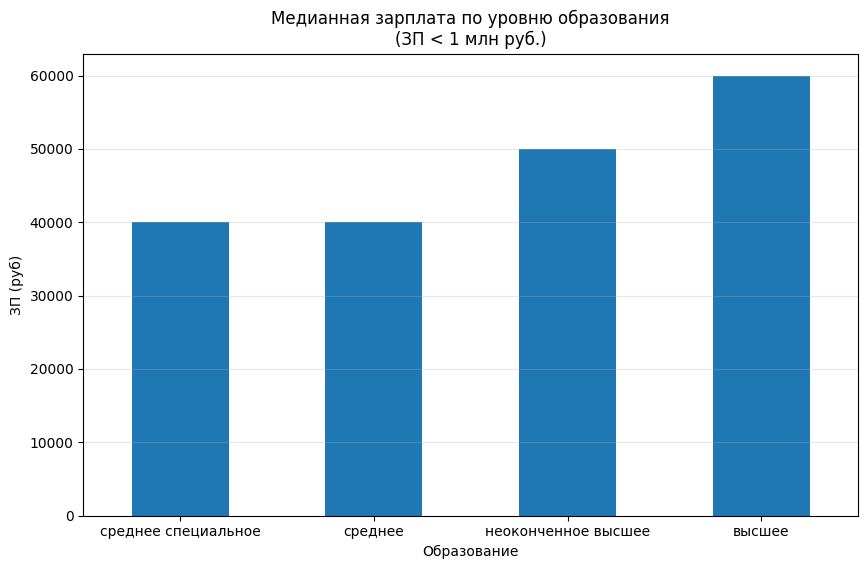

In [ ]:
df[df['ЗП (руб)'] < 1000000].groupby('Образование')['ЗП (руб)'].median().sort_values().plot(
    kind='bar',
    figsize=(10, 6),
    title='Медианная зарплата по уровню образования\n(ЗП < 1 млн руб.)',
    ylabel='ЗП (руб)',
)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Наибольшая медианная заработная плата наблюдается у соискателей с высшим образованием. Это закономерно, поскольку высшее образование обычно соответствует более квалифицированным позициям.

Наименьшая медианная заработная плата - у соискателей со средним образованием. Данная категория обычно ограничена позициями, не требующими специализированной подготовки.

Иерархия по убыванию медианной ЗП:

- Высшее образование

- Неоконченное высшее

- Среднее специальное и Среднее

Важность признака уровня образования для прогнозирования заработной платы: Признак важен - наблюдается четкая статистически значимая зависимость.Образование выступает надежным индикатором уровня зарплатных ожиданий.

Интересное наблюдение - неоконченное высшее образование демонстрирует значения, близкие к полному высшему, что может указывать на то, что работодатели ценят сам факт обучения в вузе даже без диплома.

Практическая значимость: Уровень образования является одним из ключевых факторов при прогнозировании заработной платы и должен учитываться в моделях предсказания как значимый категориальный признак.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

In [ ]:
df_filtered = df[df['ЗП (руб)'] < 1000000]
fig = px.box(
    data_frame=df_filtered,
    x='Город',
    y='ЗП (руб)',
    color='Город',
    title='Распределение з/п по городам'
)
fig.show()

medians = df_filtered.groupby('Город')['ЗП (руб)'].median().sort_values(ascending=False)
print("Медианные ЗП по городам:")
medians

Медианные ЗП по городам:


,ЗП (руб)
Город,
Москва,85000.0
Санкт-Петербург,60000.0
город-миллионник,40000.0
другие,40000.0


In [ ]:
pio.write_html(fig, 'median_salary_city.html')

Медианные уровни заработной платы демонстрируют четкую иерархию:
- Москва - наивысшая медианная ЗП
- Санкт-Петербург - второй по уровню
- Города-миллионники - третий уровень
- Другие города - наименьшие значения

Региональные различия:
- Статистические различия между Москвой и другими городами значителен (медианные значения ЗП отличается в 2.1 раза)
- Санкт-Петербург занимает промежуточное положение
- Города-миллионники демонстрируют схожие паттерны зарплатных ожиданий с другими городами - медианныя значения ЗП совпадают = 40000 руб.

Да, признак важен - город является одним из наиболее значимых факторов.
Региональные различия отражают реальные экономические диспропорции. Уровень жизни и стоимость жизни напрямую влияют на зарплатные ожидания.

При построении моделей прогнозирования заработной платы признак города должен рассматриваться как один из ключевых факторов, поскольку он объясняет существенную часть вариативности данных и соответствует экономической реальности региональных рынков труда.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

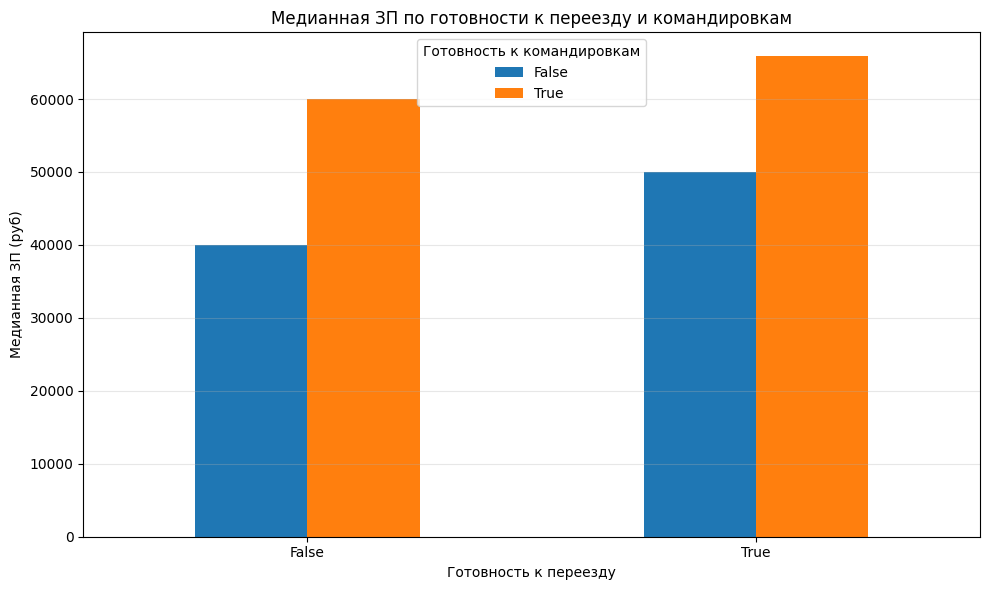

Медианные ЗП по категориям:
Готовность к командировкам    False      True 
Готовность к переезду                         
False                       40000.0  60000.000
True                        50000.0  65849.455


In [ ]:
pivot_table = df.groupby(['Готовность к переезду',
                           'Готовность к командировкам'])['ЗП (руб)'].median().unstack()
pivot_table.plot(kind='bar', figsize=(10, 6))
plt.title('Медианная ЗП по готовности к переезду и командировкам')
plt.xlabel('Готовность к переезду')
plt.ylabel('Медианная ЗП (руб)')
plt.xticks(rotation=0)
plt.legend(title='Готовность к командировкам', loc='upper center')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Медианные ЗП по категориям:")
print(pivot_table)

Наивысшая медианная заработная плата наблюдается у соискателей, готовых и к переезду, и к командировкам. Эта комбинация дает максимальный эффект на зарплатные ожидания.

Наименьшая медианная ЗП - у соискателей, не готовых ни к переезду, ни к командировкам. Ограничение мобильности существенно снижает зарплатные перспективы.

Сравнительный анализ категорий:
- Готов и к переезду, и к командировкам - наивысшая ЗП
- Не готов к переезду, но готов к командировкам - вторая по уровню
- Готов к переезду, но не готов к командировкам - третья позиция
- Не готов ни к переезду, ни к командировкам - наименьшая ЗП

Ключевая закономерность:

Готовность к командировкам оказывает более сильное влияние на уровень ЗП, чем готовность к переезду. Оба фактора независимо усиливают зарплатные ожидания. Наибольший эффект достигается при комбинации обоих факторов

Практическая интерпретация:
- Мобильные сотрудники ценятся выше на рынке труда
- Готовность к командировкам ассоциируется с более высокооплачиваемыми позициями
- Ограничение географической мобильности сужает карьерные возможности

Практическая значимость: Оба признака являются значимыми факторами при прогнозировании заработной платы и отражают ценность мобильности сотрудника для работодателей.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

In [ ]:
pivot = df.pivot_table(
    index='Образование',
    columns='Возраст',
    values='ЗП (руб)',
    aggfunc='median',
    fill_value=0
)
fig = px.imshow(
    pivot,
    aspect='auto',
    color_continuous_scale='YlOrRd',
    title='Медианная з/п по образованию и возрасту'
)
fig.show()

In [ ]:
pio.write_html(fig, 'median_salary_age_edu.html')

Ключевые наблюдения:
- "Образовательный разрыв" увеличивается с возрастом
- Неоконченное высшее близко к высшему в молодости, но отстает в зрелом возрасте
- Возрастной пик зарплат наступает раньше для соискателей со средним образованием

Взаимодействие факторов:
- Образование задает базовый уровень возможностей
- Возраст определяет траекторию роста внутри образовательной группы
- Наибольший выигрыш от высшего образования проявляется в зрелом возрасте

Практическая значимость: Оба признака критически важны для прогнозирования ЗП и демонстрируют синергетический эффект - их совместное влияние существенно превышает сумму отдельных эффектов.

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

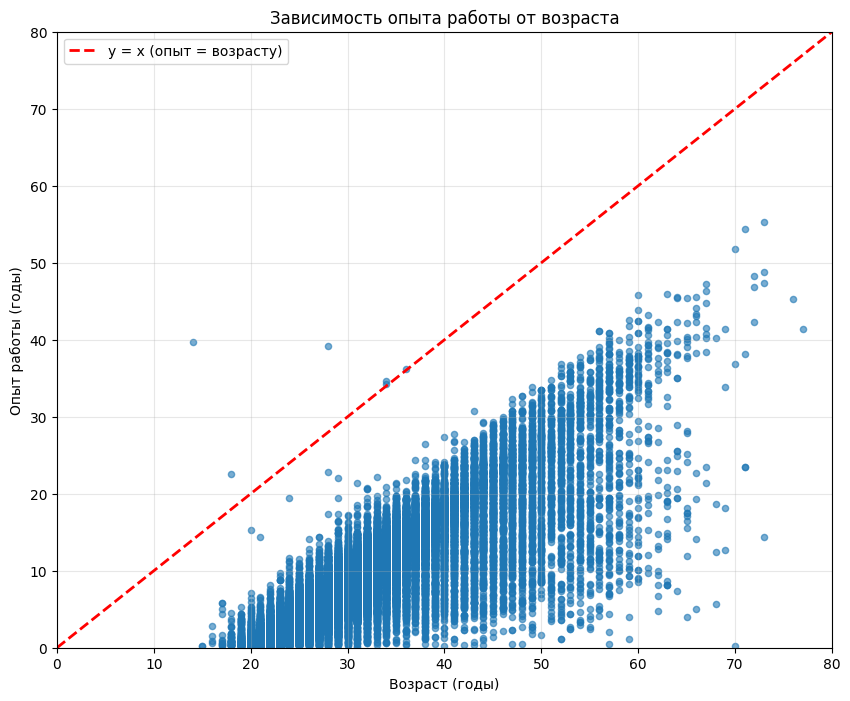

Количество точек строго выше прямой: 7
Это составляет 0.02% от всех соискателей

Статистика по аномальным точкам (опыт > возраст):
Максимальный возраст: 48 лет
Максимальный опыт: 99.0 лет
Максимальное расхождение: 51.0 лет

Примеры аномальных точек:
       Возраст  Опыт работы (годы)
4535        18           22.583333
19351       28           39.166667
19872       34           34.666667
26477       34           34.250000
29098       14           39.750000
40015       48           99.000000
43451       36           36.166667


In [ ]:
df['Опыт работы (годы)'] = df['Опыт работы (месяц)'] / 12

plt.figure(figsize=(10, 8))
plt.scatter(df['Возраст'], df['Опыт работы (годы)'], alpha=0.6, s=20)
plt.xlabel('Возраст (годы)')
plt.ylabel('Опыт работы (годы)')
plt.title('Зависимость опыта работы от возраста')

x_line = np.array([0, 100])
y_line = np.array([0, 100])
plt.plot(x_line, y_line, 'r--', linewidth=2, label='y = x (опыт = возрасту)')

plt.xlim(0, 80)
plt.ylim(0, 80)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Считаем точки строго выше прямой (опыт > возраст)
points_above_line = (df['Опыт работы (годы)'] > df['Возраст']).sum()

print(f"Количество точек строго выше прямой: {points_above_line}")
print(f"Это составляет {points_above_line/len(df)*100:.2f}% от всех соискателей")

anomalous_points = df[df['Опыт работы (годы)'] > df['Возраст']]
print(f"\nСтатистика по аномальным точкам (опыт > возраст):")
print(f"Максимальный возраст: {anomalous_points['Возраст'].max()} лет")
print(f"Максимальный опыт: {anomalous_points['Опыт работы (годы)'].max():.1f} лет")
print(f"Максимальное расхождение: {(anomalous_points['Опыт работы (годы)'] - anomalous_points['Возраст']).max():.1f} лет")
df = df.drop(columns=['Опыт работы (годы)'])

if len(anomalous_points) > 0:
    print(f"\nПримеры аномальных точек:")
    print(anomalous_points[['Возраст', 'Опыт работы (годы)']].head(10))

Подавляющее большинство точек (99.98%) расположены ниже диагональной линии. Наблюдается четкая положительная корреляция между возрастом и опытом работы

Распределение соответствует ожидаемой логике: опыт работы не может превышать возраст. Выявлено всего 7 аномальных точек (0.02% от всех соискателей). Все они расположены на диагонали или выше нее, что физически невозможно.

Возможные причины аномалий:
- Ошибки при вводе данных в резюме
- Технические сбои при обработке данных

Практическая значимость: Диаграмма демонстрирует высокое качество данных по возрасту и опыту работы. Незначительное количество аномалий не оказывает существенного влияния на общий анализ, но требует очистки перед построением прогнозных моделей.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


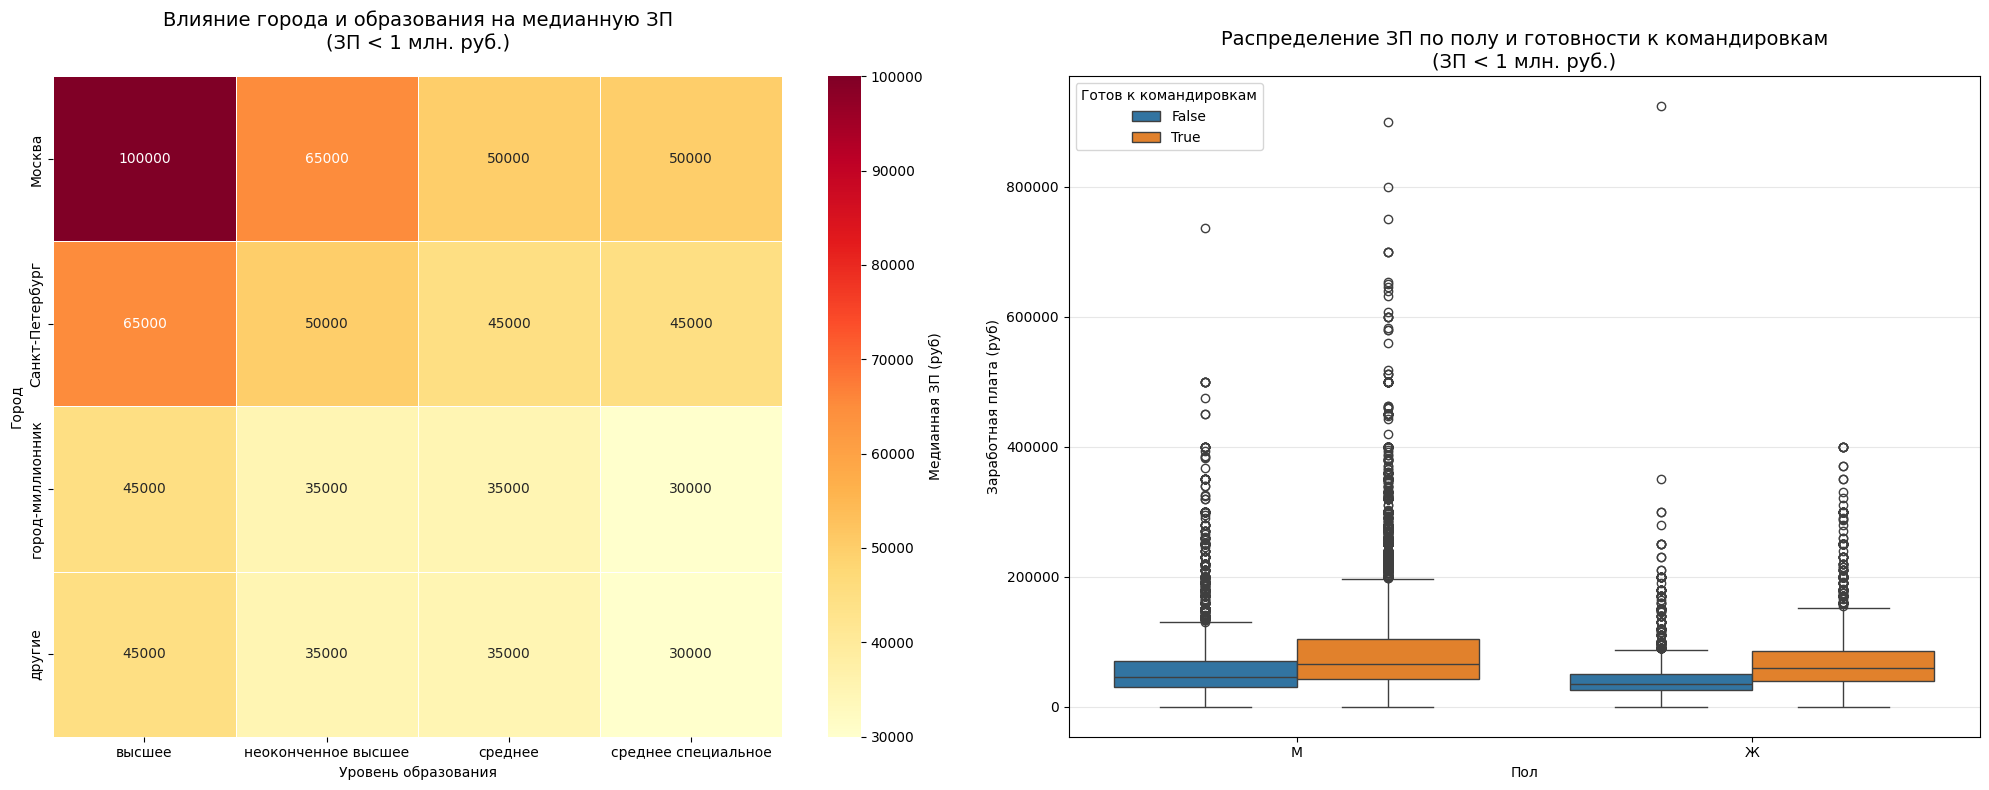

Медианные ЗП по полу и готовности к командировкам:
Пол  Готовность к командировкам
Ж    False                         35000.00
     True                          59316.25
М    False                         45000.00
     True                          65000.00
Name: ЗП (руб), dtype: float64


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Первый дополнительный график: Влияние города и образования на медианную ЗП
pivot_city_edu = df[df['ЗП (руб)'] < 1000000].pivot_table(
    values='ЗП (руб)',
    index='Город',
    columns='Образование',
    aggfunc='median'
)

heatmap = sns.heatmap(pivot_city_edu, annot=True, fmt='.0f', cmap='YlOrRd',
                      linewidths=0.5, cbar_kws={'label': 'Медианная ЗП (руб)'}, ax=ax1)
ax1.set_title('Влияние города и образования на медианную ЗП\n(ЗП < 1 млн. руб.)', fontsize=14, pad=20)
ax1.set_xlabel('Уровень образования')
ax1.set_ylabel('Город')

# Второй дополнительный график: Распределение ЗП по полу и готовности к командировкам
df_filtered = df[(df['ЗП (руб)'] < 1000000) & (df['Пол'].isin(['М', 'Ж']))]
sns.boxplot(data=df_filtered, x='Пол', y='ЗП (руб)', hue='Готовность к командировкам', ax=ax2)
ax2.set_title('Распределение ЗП по полу и готовности к командировкам\n(ЗП < 1 млн. руб.)', fontsize=14)
ax2.set_xlabel('Пол')
ax2.set_ylabel('Заработная плата (руб)')
ax2.legend(title='Готов к командировкам', loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Медианные ЗП по полу и готовности к командировкам:")
print(df_filtered.groupby(['Пол', 'Готовность к командировкам'])['ЗП (руб)'].median())

Наиболее значимые факторы (в порядке убывания важности):
- Город - Москва обеспечивает наибольший прирост ЗП во всех категориях
- Образование - высшее образование дает максимальное преимущество
- Готовность к командировкам - мобильность существенно повышает ЗП
- Пол - наблюдаются устойчивые гендерные различия

Взаимодействие факторов:
- Максимальная ЗП: Москва + высшее образование + мужской пол + готовность к командировкам
- Минимальная ЗП: Другие города + среднее/cсреднее специальное образование + женский пол + неготовность к командировкам

Региональные и образовательные паттерны:
- Москва демонстрирует наибольший разрыв между уровнями образования
- В других городах дифференциация по образованию менее выражена

Гендерные аспекты:
- Мужчины в среднем имеют более высокие зарплатные ожидания
- Готовность к командировкам выгодна для обоих полов, но дает больший абсолютный прирост мужчинам

Практическая значимость для прогнозирования: Все четыре анализируемых признака являются статистически значимыми и должны учитываться в моделях прогнозирования заработной платы. Наибольший объясняющий потенциал имеют географический и образовательный факторы.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их.

In [ ]:
df.duplicated().sum()

np.int64(161)

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах.

In [ ]:
print("Количество пропусков по столбцам:")
print(df.isnull().sum())

Количество пропусков по столбцам:
Ищет работу на должность:            0
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Обновление резюме                    0
Авто                                 0
Образование                          0
Пол                                  0
Возраст                              0
Опыт работы (месяц)                170
Город                                0
Готовность к переезду                0
Готовность к командировкам           0
Занятость полная занятость           0
Занятость частичная занятость        0
Занятость проектная работа           0
Занятость волонтерство               0
Занятость стажировка                 0
График полный день                   0
График сменный график                0
График гибкий график                 0
График удаленная работа              0
График вахтовый метод                0
ЗП (руб)                             0
dtype: int64


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [ ]:
print("Количество пропусков до обработки:")
print(df[['Опыт работы (месяц)', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность']].isnull().sum())

initial_rows = len(df)
print(f"\nИсходное количество строк: {initial_rows}")

df_cleaned = df.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])

after_deletion_rows = len(df_cleaned)
print(f"Количество строк после удаления пропусков в месте работы и должности: {after_deletion_rows}")
print(f"Удалено строк: {initial_rows - after_deletion_rows}")

median_experience = df_cleaned['Опыт работы (месяц)'].median()
print(f"\nМедианное значение опыта работы: {median_experience:.1f} месяцев")

df_cleaned = df_cleaned.copy()
df_cleaned['Опыт работы (месяц)'] = df_cleaned['Опыт работы (месяц)'].fillna(median_experience)

print("\nКоличество пропусков после обработки:")
print(df_cleaned[['Опыт работы (месяц)', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность']].isnull().sum())
print(f"\nИтоговое количество строк в датасете: {len(df_cleaned)}")
print(f"Процент сохраненных данных: {len(df_cleaned)/initial_rows*100}%")

Количество пропусков до обработки:
Опыт работы (месяц)                170
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
dtype: int64

Исходное количество строк: 44744
Количество строк после удаления пропусков в месте работы и должности: 44742
Удалено строк: 2

Медианное значение опыта работы: 100.0 месяцев

Количество пропусков после обработки:
Опыт работы (месяц)                0
Последнее/нынешнее место работы    0
Последняя/нынешняя должность       0
dtype: int64

Итоговое количество строк в датасете: 44742
Процент сохраненных данных: 99.9955301269444%


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [ ]:
print(f"Исходный размер датафрейма: {df.shape}")
outliers_low = df[df['ЗП (руб)'] < 1000]
outliers_high = df[df['ЗП (руб)'] > 1000000]

print(f"\nКоличество резюме с зарплатой ниже 1000 руб: {len(outliers_low)}")
print(f"Количество резюме с зарплатой выше 1 000 000 руб: {len(outliers_high)}")

Исходный размер датафрейма: (44744, 23)

Количество резюме с зарплатой ниже 1000 руб: 84
Количество резюме с зарплатой выше 1 000 000 руб: 5


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [ ]:
outliers = df[df['Опыт работы (месяц)'] / 12 > df['Возраст']]
print(f"Количество выбросов (опыт работы > возраста): {len(outliers)}")

Количество выбросов (опыт работы > возраста): 7


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

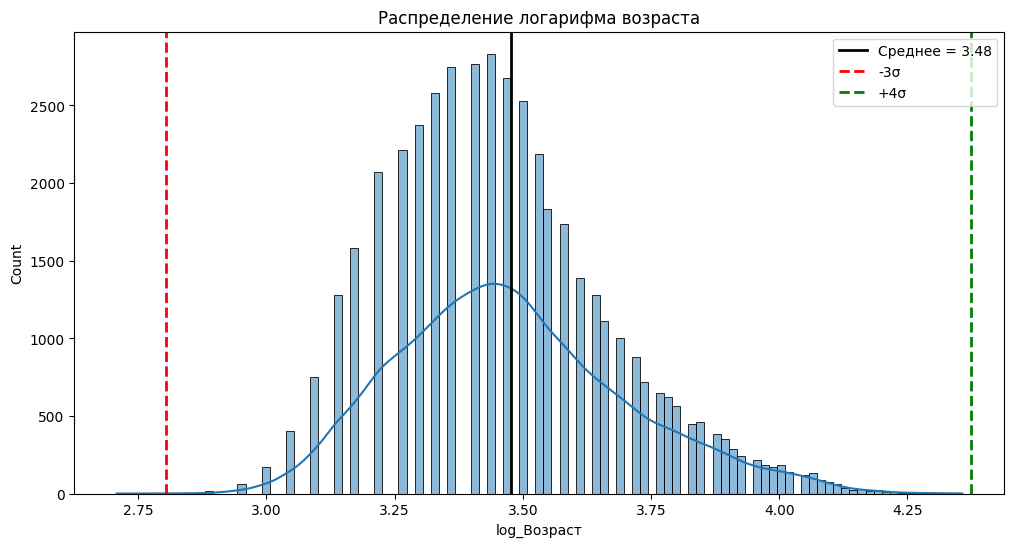

Среднее логарифма возраста: 3.48
Стандартное отклонение логарифма возраста: 0.22

Количество выбросов с помощью метода z-отклонений: 3

Таблица с выбросами:
       Возраст  log_Возраст
31137       15     2.772589
32950       15     2.772589
29098       14     2.708050

Пороговый возраст для выбросов: 79.3 лет


In [ ]:
df['log_Возраст'] = np.log(df['Возраст']+1)

# Строим распределение в логарифмическом масштабе
plt.figure(figsize=(12, 6))
histplot = sns.histplot(df['log_Возраст'], kde=True)
plt.title('Распределение логарифма возраста')

# Добавляем линии для среднего и границ 3 сигм
mean_log = df['log_Возраст'].mean()
std_log = df['log_Возраст'].std()

histplot.axvline(mean_log, color='k', lw=2, label=f'Среднее = {mean_log:.2f}')
histplot.axvline(mean_log - 3*std_log, color='r', lw=2, linestyle='--', label='-3σ')
histplot.axvline(mean_log + 4*std_log, color='g', lw=2, linestyle='--', label='+4σ')

plt.legend()
plt.show()

print(f"Среднее логарифма возраста: {mean_log:.2f}")
print(f"Стандартное отклонение логарифма возраста: {std_log:.2f}")

# Находим выбросы с помощью z-отклонения (правая сторона +4σ)
def outliers_z_score_mod(data, feature, left=3, right=3, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

outliers, cleaned_data = outliers_z_score_mod(df, 'Возраст', left=3,  right=4, log_scale=True)
print(f"\nКоличество выбросов с помощью метода z-отклонений: {len(outliers)}")

print("\nТаблица с выбросами:")
print(outliers[['Возраст', 'log_Возраст']].sort_values('Возраст', ascending=False))

threshold_age = np.exp(mean_log + 4*std_log)
print(f"\nПороговый возраст для выбросов: {threshold_age:.1f} лет")

Характер распределения в логарифмическом масштабе:
Логарифмическое распределение возраста является симметричным (приближенно к нормальному распределению). Это свидетельствует о том, что логарифмическое преобразование успешно нормализовало исходное асимметричное распределение возраста.

Обнаруженные выбросы:
- Количество выбросов: 3 соискателя
- Возраст выбросов: 14-15 лет
- Пороговый возраст: 79.3 года

Анализ выбросов:
Нижние выбросы (14-15 лет):
- Физически возможный, но статистически аномальный возраст для поиска работы
- Могут быть школьниками, ищущими подработку
- Требуют дополнительной проверки на корректность данных

Верхние выбросы:
- При использовании метода 4σ верхние выбросы отсутствуют
- Порог в 79.3 года является разумным для активного поиска работы

Метод z-отклонения в логарифмическом масштабе показал высокую эффективность. Удалено только 0.007% данных (3 наблюдения из 44742). Сохранена целостность основного массива данных.

Логарифмическое преобразование позволяет:
- Нормализовать распределение для статистического анализа
- Более точно идентифицировать выбросы
- Сохранить информативность признака после очистки

Очищенные данные лучше подходят для построения прогнозных моделей, так как исключают статистически аномальные значения, которые могут искажать результаты анализа.